# Perform NN-based error correction
NN is trained on syndromes and absolute values of the noisy signals

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os.path, sys, bz2
import pyldpc as ldpc
from tqdm.keras import TqdmCallback
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'
tf.config.list_physical_devices('GPU')

[]

In [2]:
def getBinaryMatrix(source):
    source = os.path.expanduser(source)
    fileObj = bz2.BZ2File(source, 'r') if source.endswith('bz2') else open(source, 'rt')
    with fileObj as f:
        lines = [[int(x) for x in l.strip().split()]
                  for l in f.readlines()
                  if len(l.strip()) > 0]

    if lines[0][0] in (0, 1):  # explicit 0/1 representation
        return np.array(lines, dtype=np.int)
    return alistToNumpy(lines)

def alistToNumpy(lines):
    nCols, nRows = lines[0]
    if len(lines[2]) == nCols and len(lines[3]) == nRows:
        startIndex = 4
    else:
        startIndex = 2
    matrix = np.zeros((nRows, nCols), dtype=int)
    for col, nonzeros in enumerate(lines[startIndex:startIndex + nCols]):
        for rowIndex in nonzeros:
            if rowIndex != 0:
                matrix[rowIndex - 1, col] = 1
    return matrix

In [12]:
k = 16
N = 31
T = 3
H = getBinaryMatrix('../source/BCH_31_16_3_strip.alist')
G = ldpc.coding_matrix(H, sparse=False).T

In [13]:
def full_adder(a,b,c):
    s = (a ^ b) ^ c
    c = (a & b) | (c & (a ^ b))
    return s,c

def add_bool(a,b):
    if len(a) != len(b):
        raise ValueError('arrays with different length')
    k = len(a)
    s = np.zeros(k,dtype=bool)
    c = False
    for i in reversed(range(0,k)):
        s[i], c = full_adder(a[i],b[i],c)    
    if c:
        warnings.warn("Addition overflow!")
    return s

def inc_bool(a):
    k = len(a)
    increment = np.hstack((np.zeros(k-1,dtype=bool), np.ones(1,dtype=bool)))
    a = add_bool(a,increment)
    return a

def modulateBPSK(x):
    return -2*x +1

def demodulateBPSK(x):
    return (-(np.sign(x) - 1)/2).astype(int)

def find_syndrome(x):
    return x @ H.T % 2

def errors(y_true, y_pred):
    return keras.backend.sum(int(keras.backend.not_equal(y_true, keras.backend.round(y_pred))))

def reshape_codebook(cb):
    output_shape_test = tf.reshape(cb, (-1, N+N-k, 1))
    return output_shape_test

output_shape_test = (0, 0, 0)

def gen_set(size=10000, scale=0.82, zero=False):
    """
    Generate train/test set composed of random codewords with defined AWGN level.
    
    Parameters:
    ---------
    set_size: int. Size of the train/test set (number of rows)
    scale: float. Eb/N0 level of AWGN. Default 2dB
    zero: whether is to generate set only from zero-codeword
    
    Returns:
    ---------
    codewords: original codewords
    y: modulated CWs with AWGN
    synd_inputs: syndromes noisy codewords
    abs_inputs: absolute values of noisy codewords
    error_vectors: vector with error incicating bits
    """
    
    # np.random.seed(2)
    noise = np.random.normal(loc=0, scale=scale, size=(size,N))
    rng = np.random.default_rng()
    if zero == False:
        codewords_set = rng.choice(codewords, size, replace=True)
    else:
        codewords_set = np.tile(codewords[-1], (size, 1))
    y_set = modulateBPSK(codewords_set) + noise
    synd_set = find_syndrome(demodulateBPSK(y_set))
    abs_set= np.abs(y_set)
    error_vectors_set = (codewords_set != demodulateBPSK(y_set)).astype(int)
    return codewords_set, y_set, synd_set, abs_set, error_vectors_set

In [14]:
inputs = np.zeros((2**k,k),dtype=bool)
for i in range(1,2**k):
    inputs[i]= inc_bool(inputs[i-1])
codewords = inputs @ G % 2

In [16]:
def update_model(mode):
    
    if mode == 'h-dense':
        synd_input = keras.Input(shape=(N-k,), name='synd_input')
        abs_input = keras.Input(shape=(N,), name='abs_input')
        F_input = layers.concatenate([abs_input, synd_input])
        F = layers.Dense(6*N, activation='relu')(F_input)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        F = layers.Dense(6*N, activation='relu')(F)
        F = layers.concatenate([F, F_input])
        noise_pred = layers.Dense(N, activation='sigmoid', name='noise_estimation')(F)
        model = keras.Model(inputs=[synd_input, abs_input], outputs=[noise_pred])

    elif mode == 'h-lstm':
        synd_input = keras.Input(shape=(N-k,), name='synd_input')
        abs_input = keras.Input(shape=(N,), name='abs_input')
        F_input = layers.concatenate([abs_input, synd_input])
        F_input = layers.Lambda(reshape_codebook, input_shape = (N+N-k,), output_shape = output_shape_test, name = 'reshape')(F_input)
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F_input)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu', return_sequences=True)(F)
        F = layers.concatenate([F, F_input])
        F = layers.LSTM(6*N, activation='relu')(F)
        noise_pred = layers.Dense(N, activation='sigmoid', name='noise_estimation')(F)
        model = keras.Model(inputs=[synd_input, abs_input], outputs=[noise_pred])

    elif mode == 'dense':
        synd_input = keras.Input(shape=(N-k,), name='synd_input')
        abs_input = keras.Input(shape=(N,), name='abs_input')
        F_input = layers.concatenate([abs_input, synd_input])
        F = layers.Dense(6*N, activation='relu')(F_input)
        F = layers.Dense(5*N, activation='relu')(F)
        F = layers.Dense(4*N, activation='relu')(F)
        F = layers.Dense(3*N, activation='relu')(F)
        F = layers.Dense(2*N, activation='relu')(F)
        noise_pred = layers.Dense(N, activation='sigmoid', name='noise_estimation')(F)
    model = keras.Model(inputs=[synd_input, abs_input], outputs=[noise_pred])
    model.compile(optimizer=keras.optimizers.Adam(), loss=keras.losses.BinaryCrossentropy(), metrics=errors)

    return model

## Train model

In [40]:
# Define set of test SNRs
SNR_dB_start_Eb = -10
SNR_dB_stop_Eb = 8
SNR_points = 15

SNR_dB_start_Es = SNR_dB_start_Eb + 10*np.log10(k/N)
SNR_dB_stop_Es = SNR_dB_stop_Eb + 10*np.log10(k/N)

sigma_start = np.sqrt(1/(2*10**(SNR_dB_start_Es/10)))
sigma_stop = np.sqrt(1/(2*10**(SNR_dB_stop_Es/10)))
sigmas = np.linspace(sigma_start, sigma_stop, SNR_points)

In [41]:
# base params
mode = ['h-dense']

train_size = 2**(N-k)
# test_batch = 1000000
test_batch = 1000
req_nb_errors = 2500
n_upd = 3         # Number of training set regenerations per single model fit
nb_epoch = 512    # Number of epochs per single fit procedure

nb_errors = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_errors_NN = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_frame_errors = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_frame_errors_NN = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_frames = np.zeros((len(mode),len(sigmas)),dtype=int)
nb_bits = np.zeros((len(mode),len(sigmas)),dtype=int)

for mode_i, mode_val in enumerate(mode):      # Random/zero codeword selection
#     Fit model
    model = update_model(mode_val)
    for fit_iter in range(n_upd):
        _, _, synd_input_train, abs_input_train, error_vectors_train = gen_set(size=train_size)
        model.fit(
            {"synd_input": synd_input_train, "abs_input": abs_input_train},
            error_vectors_train,
            epochs=nb_epoch,
            batch_size=2048,
            shuffle=True, 
            verbose=0, 
            callbacks=[TqdmCallback(verbose=0)])
# Eval model
    for sig_i, sigma in enumerate(sigmas):
        while (nb_errors_NN[mode_i][sig_i] < req_nb_errors):
            codewords_test, y_test, synd_input_test, abs_input_test, _ = gen_set(size=test_batch, scale=sigma)
            codewords_denoised = (demodulateBPSK(y_test) + np.round(model.predict({"synd_input": synd_input_test, "abs_input": abs_input_test})).astype(int)) % 2

            nb_frame_errors[mode_i][sig_i] += np.sum(np.any(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]), axis=1).astype(int))
            nb_frame_errors_NN[mode_i][sig_i] += np.sum(np.any(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]), axis=1).astype(int))
            nb_errors[mode_i][sig_i] += np.sum(np.not_equal(codewords_test[:, N-k:], demodulateBPSK(y_test)[:, N-k:]).astype(int))
            nb_errors_NN[mode_i][sig_i] += np.sum(np.not_equal(codewords_test[:, N-k:], codewords_denoised[:, N-k:]).astype(int))
            nb_frames[mode_i][sig_i] += test_batch
            nb_bits[mode_i][sig_i] += test_batch * k
            print(f'{mode_i+1}/{len(mode)} mode, {sig_i+1}/{len(sigmas)} test, {nb_errors_NN[mode_i][sig_i]}/{req_nb_errors} errors        ', end='\r')


0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

In [42]:
ber = nb_errors / nb_bits
ber_nn = nb_errors_NN / nb_bits
fer = nb_frame_errors / nb_frames
fer_nn = nb_frame_errors_NN / nb_frames

In [43]:
snr_ml = np.loadtxt('../source/BCH_31_16_3_ML.txt', delimiter=',')[:,0]
ber_ml = np.loadtxt('../source/BCH_31_16_3_ML.txt', delimiter=',')[:,1]

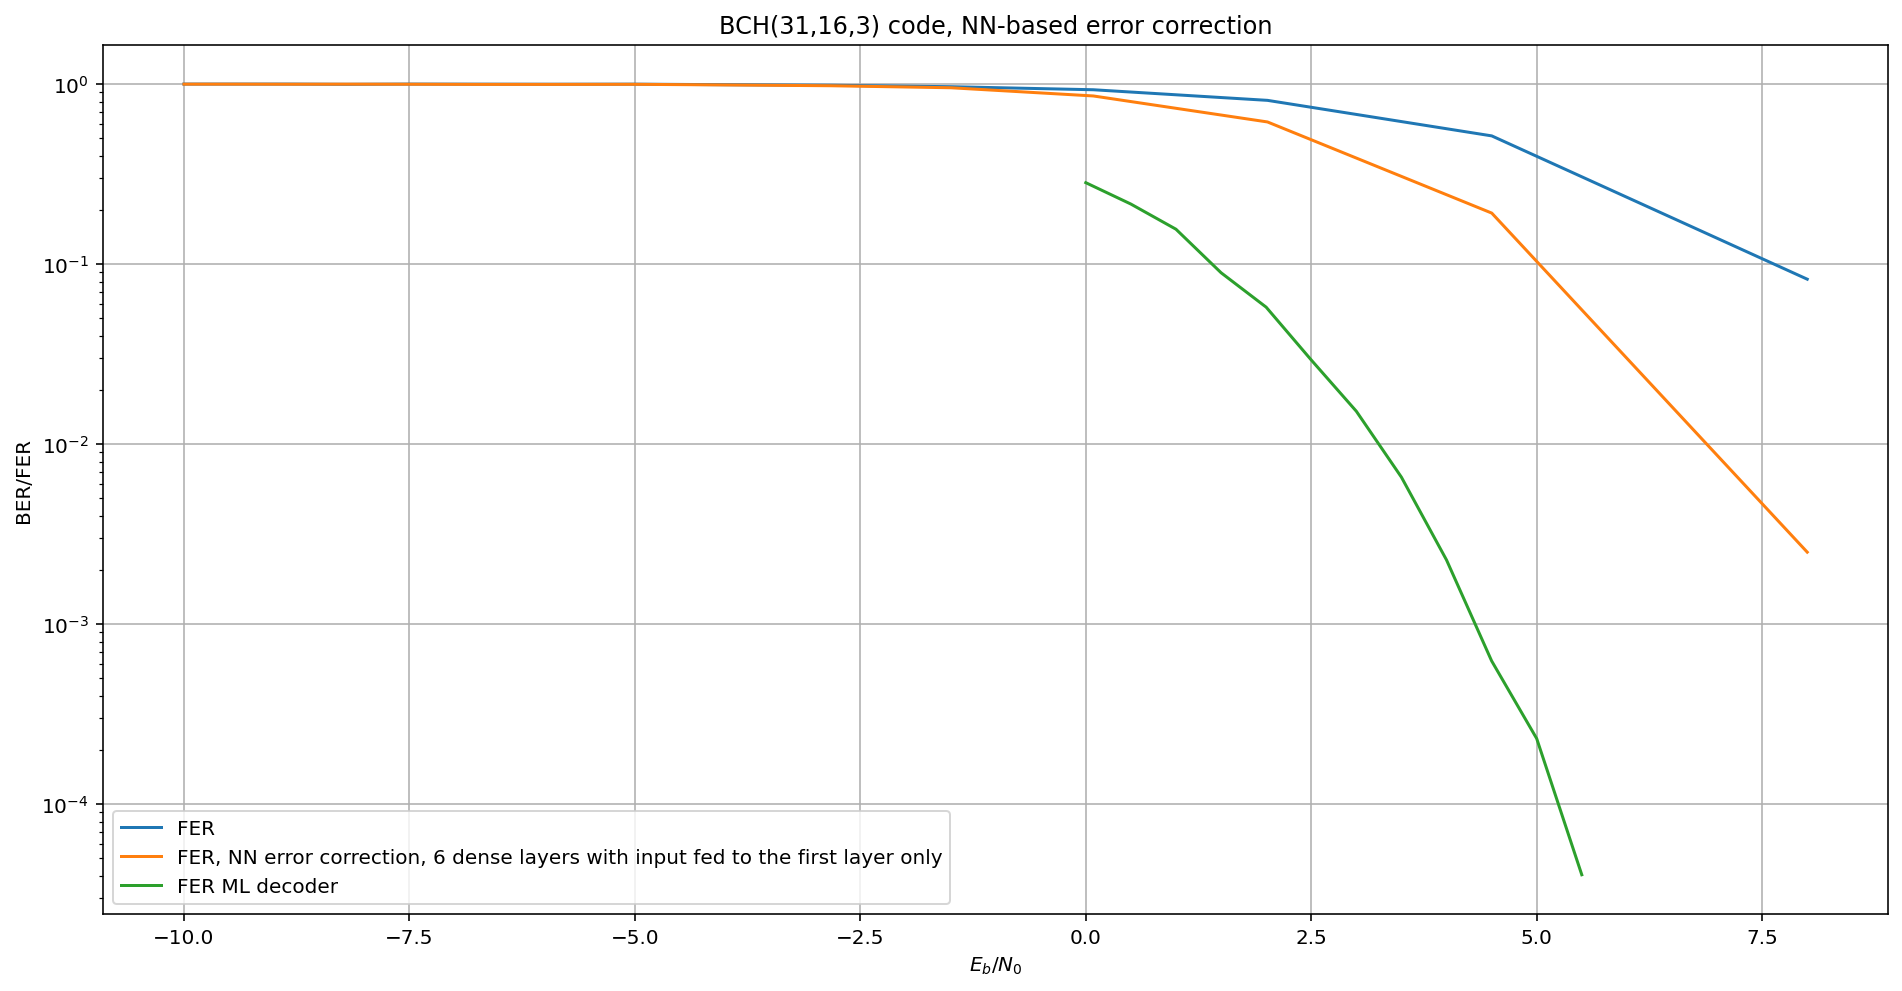

In [44]:
plt.figure(figsize = (16, 8))
# plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber[0])
# plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), ber_nn[0])

plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer[0])
plt.plot(10*np.log10(1/(2*sigmas**2)) - 10*np.log10(k/N), fer_nn[0])
plt.plot(snr_ml, ber_ml)
plt.legend([
#             'BER',
#             'BER, NN error correction, 6 dense layers with input fed to the first layer only',
            'FER',
            'FER, NN error correction, 6 dense layers with input fed to the first layer only',
            'FER ML decoder'])

# plt.xlim([0, 8])
plt.yscale('log')
plt.xlabel('$E_b/N_0$')
plt.ylabel('BER/FER')
plt.title('BCH(31,16,3) code, NN-based error correction')
plt.grid()